# Contract Clause Risk Analysis — QLoRA Fine-tuning
**Model:** LLaMA 3.1 8B Instruct  
**Method:** QLoRA (4-bit quantization + LoRA adapters)  
**Task:** Role-conditioned risk classification with Chain-of-Thought reasoning (Licensor / Licensee → Low / High)

### Before running:
1. **Accelerator** → Settings → Accelerator → **GPU T4 x2** (or P100)
2. **HF Token** → Add a Kaggle Secret named `HF_TOKEN` with your Hugging Face token (Notebook → Add-ons → Secrets). Request LLaMA 3.1 access at hf.co/meta-llama if needed.
3. **Dataset files** → Upload `train.jsonl` and `val.jsonl` as a Kaggle Dataset (+ Add data → New Dataset), then attach it. They will appear under `/kaggle/input/<dataset-name>/`
   - Update `TRAIN_FILE` / `VAL_FILE` in the Config cell to match your dataset path.
4. **Internet** → Must be **ON** (Settings → Internet → On) to pull model weights from HF.
5. Outputs are saved to `/kaggle/working/qlora_output/` — download them from the Output tab when done.

## 1. Install Dependencies

In [ ]:
%%capture
# Install the base dependencies
!pip install -q \
    numpy==1.26.4 \
    transformers<4.46.0 \
    triton==2.2.0 \
    bitsandbytes>=0.46.1 \
    accelerate==0.33.0 \
    datasets==2.21.0 \
    huggingface-hub==0.23.4 \
    scikit-learn \
    seaborn \
    matplotlib

# Force-install peft and trl while ignoring their dependency demands
!pip install -q --no-deps peft==0.12.0 trl==0.8.6

print('✓ Packages installed')

In [ ]:
!pip install -U bitsandbytes>=0.46.1

In [ ]:
!pip install "transformers<4.46.0"

In [ ]:
# pip install tyro>=0.5.11
!pip install trl==0.8.6

## 2. Hugging Face Login

In [ ]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

secrets = UserSecretsClient()
hf_token = secrets.get_secret('HF_TOKEN')
login(token=hf_token)
print('✓ Logged in to Hugging Face')

## 3. Config — all hyperparameters in one place

**Key changes from original:**
- `LORA_MODULES` reduced from 7 → 2 (attention only): ~60-70% fewer trainable params
- `LORA_RANK` 16 → 8: sufficient for binary classification
- `BATCH_SIZE` 2 → 4: safe now that LoRA is leaner
- `GRAD_ACCUM` 8 → 4: effective batch stays at 16
- `MAX_SEQ_LEN` 512 → 768: gives CoT reasoning room to breathe
- Eval/save strategy changed to per-epoch: removes ~12 redundant eval passes per epoch
- Hub push strategy changed to end-only: eliminates mid-training upload stalls

In [21]:
import os

# ── Paths ──────────────────────────────────────────────────────
TRAIN_FILE  = "/kaggle/input/datasets/aaravsinghluthra/merged-balanced/train_balanced.jsonl"
VAL_FILE    = "/kaggle/input/datasets/aaravsinghluthra/merged-balanced/val.jsonl"
OUTPUT_DIR  = "/kaggle/working/qlora_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Model ──────────────────────────────────────────────────────
MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"

# ── QLoRA ──────────────────────────────────────────────────────
LORA_RANK    = 8               # was 16 — rank 8 is sufficient for binary classification
LORA_ALPHA   = 16              # keep 2x rank
LORA_DROPOUT = 0.05
LORA_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"] # was 7 modules — attention-only is faster & enough

# ── Training ───────────────────────────────────────────────────
EPOCHS       = 3
BATCH_SIZE   = 1               # was 2 — safe now that LoRA footprint is smaller
GRAD_ACCUM   = 16               # effective batch = 4 * 4 = 16 (same as before)
LR           = 2e-4
MAX_SEQ_LEN  = 768             # was 512 — CoT reasoning needs more room
WARMUP_RATIO = 0.1

SEED = 42

print(f'✓ Config set. Outputs → {OUTPUT_DIR}')
print(f'  Trainable modules : {LORA_MODULES}')
print(f'  LoRA rank         : {LORA_RANK}')
print(f'  Effective batch   : {BATCH_SIZE * GRAD_ACCUM}')
print(f'  Max seq length    : {MAX_SEQ_LEN}')
print(f'  Train: {TRAIN_FILE}')
print(f'  Val  : {VAL_FILE}')

✓ Config set. Outputs → /kaggle/working/qlora_output
  Trainable modules : ['q_proj', 'k_proj', 'v_proj', 'o_proj']
  LoRA rank         : 8
  Effective batch   : 16
  Max seq length    : 768
  Train: /kaggle/input/datasets/aaravsinghluthra/merged-balanced/train_balanced.jsonl
  Val  : /kaggle/input/datasets/aaravsinghluthra/merged-balanced/val.jsonl


## 4. Validate Dataset Format
Sanity-check that every example ends with a well-formed `Risk Level: Low/High` terminal label. Malformed examples silently teach the model to drop the label or place it randomly.

In [22]:
import json, re

def check_terminal_label(text: str) -> bool:
    """Returns True if the text ends with a valid Risk Level label."""
    return bool(re.search(r"Risk Level:\s*(Low|High)\s*$", text, re.IGNORECASE | re.MULTILINE))

for split_name, fpath in [("train", TRAIN_FILE), ("val", VAL_FILE)]:
    examples = []
    with open(fpath) as f:
        for line in f:
            line = line.strip()
            if line:
                examples.append(json.loads(line))

    malformed = [i for i, ex in enumerate(examples) if not check_terminal_label(ex["text"])]

    print(f"[{split_name}] Total: {len(examples)} | Malformed: {len(malformed)}")
    if malformed:
        print(f"  ⚠️  First bad indices: {malformed[:5]}")
        print(f"  Tail of first bad example:\n{examples[malformed[0]]['text'][-400:]}")
    else:
        print(f"  ✓ All examples have a valid terminal label")

[train] Total: 3975 | Malformed: 0
  ✓ All examples have a valid terminal label
[val] Total: 826 | Malformed: 0
  ✓ All examples have a valid terminal label


## 5. Load Dataset

In [23]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files={"train": TRAIN_FILE, "validation": VAL_FILE}
)
""
print(dataset)
print("\nSample training example:")
print(dataset["train"][0]["text"])

DatasetDict({
    train: Dataset({
        features: ['text', '_meta'],
        num_rows: 3975
    })
    validation: Dataset({
        features: ['text', '_meta'],
        num_rows: 826
    })
})

Sample training example:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a legal risk analyst specializing in licensing agreements. Your task is to analyze a contract clause and assess its risk level from a specific party's perspective. Focus on the practical consequences for the party — what they stand to lose, what obligations they must perform, and how protected they are if things go wrong. As a rough guide: low risk implies little to no liability for the party, and high risk implies exposure.<|eot_id|><|start_header_id|>user<|end_header_id|>

Analyze the following contract clause from the perspective of the **Licensor**.

Clause:
"""
2.3 Notwithstanding anything to the contrary in this Agreement, PFHOF shall have the right to approve (in its sole and absolute discret

## 6. Load Model in 4-bit (QLoRA)

In [24]:
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)


bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",             # NormalFloat4 — best for normally distributed weights
    bnb_4bit_compute_dtype=torch.bfloat16, # compute in bf16 for stability
    bnb_4bit_use_double_quant=True,        # quantize quantization constants too (~0.4 GB saved)
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token  # LLaMA has no pad token by default
tokenizer.padding_side = "right"           # pad on right for causal LM training

print(f"✓ Model loaded. Parameters: {model.num_parameters()/1e9:.1f}B")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Model loaded. Parameters: 8.0B


## 7. Attach LoRA Adapters

In [27]:
import gc
import torch

# 1. Delete the specific large variables you no longer need
# del my_model, my_large_tensor, my_dataset 

# 2. Run Python garbage collection
gc.collect()

# 3. Clear PyTorch's CUDA cache
torch.cuda.empty_cache()

In [28]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)
model.config.use_cache = False

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_MODULES,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# With rank=8 and 2 modules, expect ~0.1-0.2% trainable — much leaner than before

trainable params: 6,815,744 || all params: 8,037,076,992 || trainable%: 0.0848


## 8. (Optional) Resume from Checkpoint
Only run this cell if you are resuming from a previous run. Skip for a fresh training run.

In [29]:
# ── Only run this if resuming ──────────────────────────────────
# from huggingface_hub import snapshot_download
# import os
#
# print("Downloading checkpoint from Hugging Face...")
# local_dir = snapshot_download(
#     repo_id="Saksham-Bali/llama-3.1-8b-legal-risk-qlora",
#     local_dir="/kaggle/working/hf_checkpoints"
# )
# checkpoint_path = os.path.join(local_dir, "last-checkpoint")
# print(f"✓ Checkpoint ready: {checkpoint_path}")

print("Skipping checkpoint resume — starting fresh training.")
checkpoint_path = None

Skipping checkpoint resume — starting fresh training.


## 9. Train

**Key changes from original:**
- `gradient_checkpointing=True` explicitly set in TrainingArguments
- `eval_strategy="epoch"` / `save_strategy="epoch"` — removes ~12 unnecessary eval passes per epoch
- `hub_strategy="end"` — eliminates mid-training HuggingFace upload stalls
- `EarlyStoppingCallback` patience raised to 5 (was 3 — too aggressive at per-epoch eval)
- `packing=False` — safer for CoT data with variable-length reasoning; avoids truncating mid-explanation
- `DataCollatorForSeq2Seq` with `pad_to_multiple_of=8` — reduces padding waste on variable-length CoT outputs

In [30]:
from transformers import TrainingArguments, EarlyStoppingCallback, DataCollatorForSeq2Seq
from trl import SFTTrainer

# Efficient collator: pads to actual batch max length (not global max),
# aligned to 8 for tensor core efficiency
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    pad_to_multiple_of=8,
    padding=True,
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},           # explicit — frees VRAM for larger batch
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    bf16=False,
    fp16=True,            # fp16 uses less VRAM than bf16 on T4
    logging_steps=20,
    eval_strategy="epoch",                 # was "steps" — removes ~12 eval passes/epoch
    save_strategy="epoch",                 # matches eval strategy for load_best_model_at_end
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",                      # set to "wandb" if you want experiment tracking
    seed=SEED,

    # ── HuggingFace Hub ───────────────────────────────────────────
    push_to_hub=True,
    hub_model_id="the-noble1/llama-3.1-8b-legal-risk-qlora",
    hub_strategy="end",                    # was "checkpoint" — eliminates upload stalls mid-training
    hub_private_repo=True,
    # ─────────────────────────────────────────────────────────────
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=tokenizer,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LEN,
    packing=False,                         # safer for CoT — avoids truncating mid-reasoning
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

print("Starting training...")
print(f"  Steps per epoch : ~{len(dataset['train']) // (BATCH_SIZE * GRAD_ACCUM)}")
print(f"  Total steps     : ~{len(dataset['train']) // (BATCH_SIZE * GRAD_ACCUM) * EPOCHS}")

if checkpoint_path:
    import torch
    from unittest.mock import patch

    original_load = torch.load
    def legacy_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return original_load(*args, **kwargs)

    print(f"Resuming from checkpoint: {checkpoint_path}")
    with patch('torch.load', side_effect=legacy_load):
        trainer.train(resume_from_checkpoint=checkpoint_path)
else:
    import os
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # makes errors synchronous and easier to debug
    trainer.train()

print("✓ Training complete.")

Starting training...
  Steps per epoch : ~248
  Total steps     : ~744


Epoch,Training Loss,Validation Loss
0,0.645400,0.660426
1,0.525400,0.651159
2,0.430100,0.668440


✓ Training complete.


## 10. Save LoRA Adapter Weights

In [31]:
import os, json as _json, datetime

trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

run_info = {
    "model_id"   : MODEL_ID,
    "lora_rank"  : LORA_RANK,
    "lora_alpha" : LORA_ALPHA,
    "lora_modules": LORA_MODULES,
    "epochs"     : EPOCHS,
    "lr"         : LR,
    "batch_size" : BATCH_SIZE,
    "grad_accum" : GRAD_ACCUM,
    "max_seq_len": MAX_SEQ_LEN,
    "task"       : "binary (Low/High) + CoT reasoning",
    "saved_at"   : datetime.datetime.now().isoformat(),
}
with open(os.path.join(OUTPUT_DIR, "run_info.json"), "w") as f:
    _json.dump(run_info, f, indent=2)

saved_files = os.listdir(OUTPUT_DIR)
print(f"\n✓ Adapter saved to: {OUTPUT_DIR}")
print(f"  Files: {sorted(saved_files)}")
print("\nTo reload later:")
print(f"  from peft import PeftModel")
print(f"  model = PeftModel.from_pretrained(base_model, '{OUTPUT_DIR}')")


✓ Adapter saved to: /kaggle/working/qlora_output
  Files: ['README.md', 'adapter_config.json', 'adapter_model.safetensors', 'checkpoint-248', 'checkpoint-496', 'checkpoint-744', 'run_info.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json']

To reload later:
  from peft import PeftModel
  model = PeftModel.from_pretrained(base_model, '/kaggle/working/qlora_output')


In [32]:
# Run this before trainer.train() to confirm you're actually on GPU
import torch
print(torch.cuda.get_device_name(0))
print(f"Memory allocated: {torch.cuda.memory_allocated()/1e9:.1f} GB")

Tesla T4
Memory allocated: 3.0 GB


## 11. Evaluate — Extract Predictions on Val Set

**Key changes from original:**
- `extract_risk_label` now takes the **last** match in generated text — CoT output mentions risk levels in reasoning before the final verdict, so the first match is unreliable
- `max_new_tokens` raised to 200 to accommodate reasoning + label output
- Backup logic retained (write to local JSONL + periodic HF upload every 100 steps)

In [33]:
import json, re, torch
from tqdm import tqdm
from huggingface_hub import HfApi

# ── Label extraction — takes the LAST match (after CoT reasoning) ──────────
def extract_risk_label(generated_text: str) -> str:
    """
    For CoT outputs: reasoning comes first, label comes last.
    Taking the LAST occurrence of Low/High is critical — the reasoning
    may mention risk levels before landing on the final verdict.
    """
    # Prefer an explicit 'Risk Level:' marker at the end
    match = re.search(r"Risk Level:\s*(Low|High)\s*$", generated_text, re.IGNORECASE | re.MULTILINE)
    if match:
        return match.group(1).capitalize()
    # Fallback: take the last standalone Low/High in the output
    matches = re.findall(r"\b(Low|High)\b", generated_text, re.IGNORECASE)
    if matches:
        return matches[-1].capitalize()  # LAST, not first
    return "Unknown"

def get_prompt_only(full_text: str) -> str:
    marker = "<|start_header_id|>assistant<|end_header_id|>\n\n"
    idx = full_text.find(marker)
    if idx != -1:
        return full_text[:idx + len(marker)]
    return full_text

def get_ground_truth_label(full_text: str) -> str:
    marker = "<|start_header_id|>assistant<|end_header_id|>\n\n"
    idx = full_text.find(marker)
    if idx != -1:
        response = full_text[idx + len(marker):]
        return extract_risk_label(response)
    return "Unknown"

# ── Load val examples ──────────────────────────────────────────
val_examples = []
with open(VAL_FILE) as f:
    for line in f:
        line = line.strip()
        if line:
            val_examples.append(json.loads(line))

print(f"Running inference on {len(val_examples)} validation examples...")

model.eval()
y_true, y_pred, parties = [], [], []

# ── Cloud backup setup ────────────────────────────────────────
api = HfApi()
repo_id = "the-noble1/llama-3.1-8b-legal-risk-qlora"
local_backup_path = "/kaggle/working/inference_backup.jsonl"
output_file = open(local_backup_path, "w")

for i, ex in enumerate(tqdm(val_examples)):
    full_text = ex["text"]
    prompt    = get_prompt_only(full_text)
    gt_label  = get_ground_truth_label(full_text)
    party     = ex.get("_meta", {}).get("party", "Unknown")

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LEN)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=200,            # was 80 — CoT reasoning needs more tokens
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    generated  = tokenizer.decode(new_tokens, skip_special_tokens=True)
    pred_label = extract_risk_label(generated)

    # Write to local backup immediately
    result_dict = {"index": i, "true": gt_label, "pred": pred_label, "party": party, "generated": generated}
    output_file.write(json.dumps(result_dict) + "\n")
    output_file.flush()

    y_true.append(gt_label)
    y_pred.append(pred_label)
    parties.append(party)

    # Upload to HuggingFace every 100 steps as backup
    if (i + 1) % 100 == 0:
        try:
            api.upload_file(
                path_or_fileobj=local_backup_path,
                path_in_repo="inference_backup.jsonl",
                repo_id=repo_id,
                repo_type="model"
            )
        except Exception:
            pass  # ignore transient network blips

output_file.close()

# Final upload
api.upload_file(
    path_or_fileobj=local_backup_path,
    path_in_repo="inference_backup.jsonl",
    repo_id=repo_id,
    repo_type="model"
)
print("✓ Inference complete and backed up to HuggingFace.")

Running inference on 826 validation examples...


  0%|          | 0/826 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)
100%|██████████| 826/826 [1:19:25<00:00,  5.77s/it]


RepositoryNotFoundError: 404 Client Error. (Request ID: Root=1-69f0f898-4b83c4cb3e7ea2016fa2536b;507c08a4-725c-4e90-9241-be3b4da2d662)

Repository Not Found for url: https://huggingface.co/api/models/Saksham-Bali/llama-3.1-8b-legal-risk-qlora/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.

## 12. Performance Metrics

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

LABELS = ["Low", "High"]

# ── Overall metrics ───────────────────────────────────────────
print("=" * 55)
print("OVERALL PERFORMANCE (val set)")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}")
print()
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

# ── Per-party metrics ─────────────────────────────────────────
for party in ["Licensor", "Licensee"]:
    idx = [i for i, p in enumerate(parties) if p == party]
    if not idx:
        continue
    pt = [y_true[i] for i in idx]
    pp = [y_pred[i] for i in idx]
    print(f"{'=' * 55}")
    print(f"{party.upper()} (n={len(idx)})")
    print(f"{'=' * 55}")
    print(f"Accuracy: {accuracy_score(pt, pp):.3f}")
    print(classification_report(pt, pp, labels=LABELS, zero_division=0))

OVERALL PERFORMANCE (val set)
Accuracy: 0.815

              precision    recall  f1-score   support

         Low       0.84      0.91      0.88       597
        High       0.71      0.56      0.63       229

    accuracy                           0.81       826
   macro avg       0.78      0.74      0.75       826
weighted avg       0.81      0.81      0.81       826

LICENSOR (n=413)
Accuracy: 0.835
              precision    recall  f1-score   support

         Low       0.87      0.94      0.90       336
        High       0.59      0.39      0.47        77

    accuracy                           0.84       413
   macro avg       0.73      0.66      0.69       413
weighted avg       0.82      0.84      0.82       413

LICENSEE (n=413)
Accuracy: 0.794
              precision    recall  f1-score   support

         Low       0.81      0.88      0.84       261
        High       0.76      0.64      0.70       152

    accuracy                           0.79       413
   macro avg   

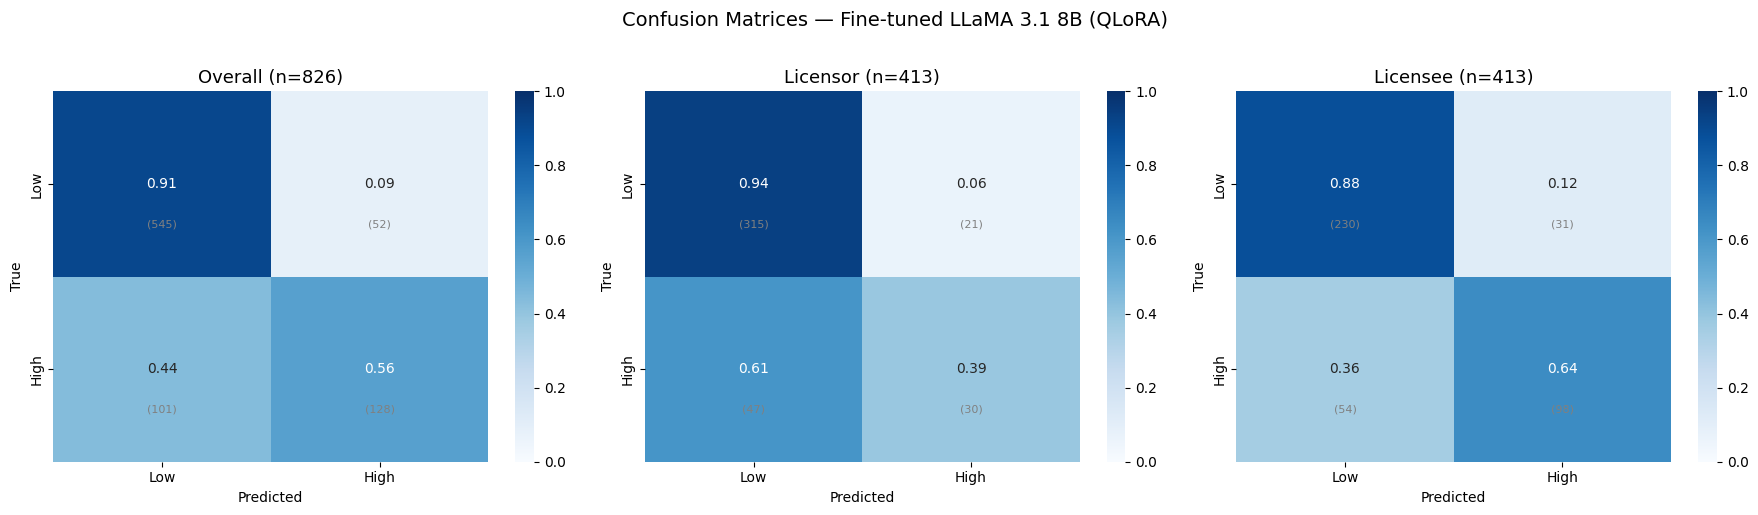

✓ Saved: /kaggle/working/qlora_output/confusion_matrices.png


In [35]:
# ── Confusion matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = [
    ("Overall",  list(range(len(y_true))), y_true, y_pred),
    ("Licensor", [i for i, p in enumerate(parties) if p == "Licensor"], None, None),
    ("Licensee", [i for i, p in enumerate(parties) if p == "Licensee"], None, None),
]

for ax, (title, idx, yt, yp) in zip(axes, splits):
    if yt is None:
        yt = [y_true[i] for i in idx]
        yp = [y_pred[i] for i in idx]
    cm = confusion_matrix(yt, yp, labels=LABELS)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=LABELS, yticklabels=LABELS, ax=ax,
        vmin=0, vmax=1,
    )
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j + 0.5, i + 0.72, f"({cm[i,j]})",
                    ha="center", va="center", fontsize=8, color="gray")
    ax.set_title(f"{title} (n={len(yt)})", fontsize=13)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices — Fine-tuned LLaMA 3.1 8B (QLoRA)", fontsize=14, y=1.02)
plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, "confusion_matrices.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {cm_path}")

In [36]:
# ── High↔Low flip analysis ────────────────────────────────────
flips = [
    (i, y_true[i], y_pred[i], parties[i])
    for i in range(len(y_true))
    if set([y_true[i], y_pred[i]]) == {"High", "Low"}
]

print(f"High↔Low flips: {len(flips)} / {len(y_true)} ({len(flips)/len(y_true):.1%})")
if flips:
    print(f"{'Idx':>4}  {'True':>7}  {'Pred':>7}  Party")
    print("-" * 35)
    for idx, true, pred, party in flips[:20]:  # show first 20
        print(f"{idx:>4}  {true:>7}  {pred:>7}  {party}")

High↔Low flips: 153 / 826 (18.5%)
 Idx     True     Pred  Party
-----------------------------------
   5      Low     High  Licensor
  14      Low     High  Licensee
  16     High      Low  Licensor
  17      Low     High  Licensor
  21     High      Low  Licensee
  22     High      Low  Licensor
  25     High      Low  Licensor
  30      Low     High  Licensor
  33     High      Low  Licensee
  36     High      Low  Licensor
  51     High      Low  Licensor
  54     High      Low  Licensee
  59     High      Low  Licensor
  62     High      Low  Licensee
  71      Low     High  Licensor
  77      Low     High  Licensee
  80     High      Low  Licensor
  84     High      Low  Licensor
  85     High      Low  Licensor
  89     High      Low  Licensee


In [37]:
# ── Prediction distribution ───────────────────────────────────
from collections import Counter

print("Prediction distribution (val):")
pred_dist = Counter(y_pred)
true_dist = Counter(y_true)
unknown_count = pred_dist.get("Unknown", 0)

print(f"{'Label':>8}  {'True':>6}  {'Pred':>6}")
print("-" * 26)
for label in LABELS:
    print(f"{label:>8}  {true_dist[label]:>6}  {pred_dist[label]:>6}")

if unknown_count > 0:
    print(f"\n⚠️  {unknown_count} 'Unknown' predictions ({unknown_count/len(y_pred):.1%}) — model not terminating with 'Risk Level: Low/High'")
    print("   Check MAX_SEQ_LEN and max_new_tokens — reasoning may be getting truncated.")
else:
    print("\n✓ No 'Unknown' predictions — label extraction is clean.")

Prediction distribution (val):
   Label    True    Pred
--------------------------
     Low     597     646
    High     229     180

✓ No 'Unknown' predictions — label extraction is clean.


## 13. Qualitative Check — Sample Predictions
Inspects full CoT output for correct, incorrect, and High-risk examples.

In [38]:
import textwrap

def show_sample(idx):
    ex = val_examples[idx]
    prompt = get_prompt_only(ex["text"])
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LEN)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=250,            # was 120 — extra room for full CoT output
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    generated = tokenizer.decode(new_tokens, skip_special_tokens=True)

    party  = ex.get("_meta", {}).get("party", "?")
    true_l = y_true[idx]
    pred_l = y_pred[idx]
    match  = "✓" if true_l == pred_l else "✗"

    print(f"{'─' * 60}")
    print(f"Example #{idx}  |  Party: {party}  |  True: {true_l}  |  Pred: {pred_l}  {match}")
    print(f"{'─' * 60}")
    print("Generated output (reasoning + label):")
    print(textwrap.fill(generated.strip(), width=80))
    print()

correct_idx   = next((i for i in range(len(y_true)) if y_true[i] == y_pred[i]), 0)
incorrect_idx = next((i for i in range(len(y_true)) if y_true[i] != y_pred[i]), 1)
high_idx      = next((i for i in range(len(y_true)) if y_true[i] == "High"), 2)
low_idx       = next((i for i in range(len(y_true)) if y_true[i] == "Low"), 3)

for idx in [correct_idx, incorrect_idx, high_idx, low_idx]:
    show_sample(idx)

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


────────────────────────────────────────────────────────────
Example #0  |  Party: Licensor  |  True: Low  |  Pred: Low  ✓
────────────────────────────────────────────────────────────
Generated output (reasoning + label):
Risk Level: Low Explanation: The clause only limits the Licensor’s ability to
claim indirect damages, which is a standard limitation and does not create a
significant cost or restriction.

────────────────────────────────────────────────────────────
Example #5  |  Party: Licensor  |  True: Low  |  Pred: High  ✗
────────────────────────────────────────────────────────────
Generated output (reasoning + label):
Risk Level: High Explanation: The Licensor cannot guarantee the content or its
accuracy and is not liable for any damages, limiting its liability.

────────────────────────────────────────────────────────────
Example #8  |  Party: Licensee  |  True: High  |  Pred: High  ✓
────────────────────────────────────────────────────────────
Generated output (reasoning + la

## 14. Load Fine-tuned Weights for Inference Only
Only run this section if you want to run inference without training (e.g. in a separate notebook).

In [ ]:
# ── Only run this block for inference-only usage ───────────────
# from peft import PeftModel
# from huggingface_hub import snapshot_download
#
# local_dir = snapshot_download(
#     repo_id="Saksham-Bali/llama-3.1-8b-legal-risk-qlora",
#     local_dir="/kaggle/working/hf_checkpoints"
# )
# checkpoint_path = os.path.join(local_dir, "last-checkpoint")
#
# model = PeftModel.from_pretrained(model, checkpoint_path)
# print("✓ Fine-tuned weights loaded. Ready for inference.")

print("Inference-only block is commented out. Uncomment to use.")